# BBO11_2: Simplified GP+UCB with Selective Clustering

## Evidence-Based Simplification from BBO10/BBO11

After analysing F1–F8 data, three key findings drive this redesign:

| Finding | Implication | Action |
|---|---|---|
| HPO (Optuna) improves GP CV score by < 0.001 on all 8 functions | Marginal gain, high runtime cost | **Remove HPO entirely** |
| Clustering silhouette < 0.20 (F8) or weak signal (F6, F7) means forced clusters mislead acquisition | Clustering should be conditional | **Gate on silhouette ≥ 0.22** |
| CNN gradient predictor & residual corrector require > 10× more runtime than GP alone; LOO-MAE / y_range already low (< 0.13 for 6/8 functions) | GP alone is well-calibrated | **Remove CNN stack** |

## What remains

```
fit_gp()          — CV kernel selection (RBF, Matérn 1.5, Matérn 2.5)
cluster_analysis() — KMeans k* via silhouette (gated, k=2..6)
acquire()         — UCB + optional cluster score blend + L-BFGS-B
```

Three functions, ~120 lines total. Retains the gap-injection and 
density-aware weighting from BBO11 but only when clusters are real.

## Clustering impact per function

| Fn | n  | d | k* | Silhouette | Verdict        |
|----|----|---|----|------------|----------------|
| F1 | 20 | 2 | 3  | 0.516      | **STRONG** — used |
| F2 | 20 | 2 | 2  | 0.490      | **STRONG** — used |
| F3 | 25 | 3 | 6  | 0.354      | MODERATE — used |
| F4 | 40 | 4 | 6  | 0.260      | MODERATE — used |
| F5 | 30 | 4 | 5  | 0.312      | MODERATE — used |
| F6 | 30 | 5 | 2  | 0.225      | WEAK — used (borderline) |
| F7 | 40 | 6 | 4  | 0.235      | WEAK — used (borderline) |
| F8 | 50 | 8 | 6  | 0.154      | **TOO WEAK** — skipped |

F8 has 50 observations in 8D: the space is too sparse for meaningful 
natural groupings. Clustering would impose false structure.


In [10]:
"""
BBO11_2: Simplified Black Box Optimisation
=========================================
Retains from BBO11:
  - CV-based kernel selection (no HPO)
  - Cluster-aware acquisition (gated on silhouette quality)
  - Gap midpoint injection
  - L-BFGS-B local refinement

Removed from BBO10/BBO11:
  - Optuna HPO for GP noise / alpha / restarts     [< 0.001 CV gain]
  - CNN gradient predictor (GradientPredictorCNN)  [runtime >> benefit]
  - CNN residual corrector (ResidualCorrectorCNN)  [GP already well-calibrated]
  - Acquisition kappa/sv_weight HPO               [fixed kappa=4 is sufficient]
  - Gradient-enhanced GP augmentation             [adds complexity without gain here]
"""

import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern, ConstantKernel, WhiteKernel
from sklearn.model_selection import cross_val_score
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.optimize import minimize
from scipy.spatial.distance import cdist

print("BBO11_2 imports OK")


BBO11_2 imports OK


## Part 1: GP Infrastructure

In [11]:
# ═══════════════════════════════════════════════════════════════
# PART 1: GP — CV-based kernel selection (no HPO)
# ═══════════════════════════════════════════════════════════════

def fit_best_gp(X_obs, y_obs):
    """
    Select the best GP kernel using cross-validated negative MSE.

    Tries three ARD kernels: RBF, Matérn-2.5, Matérn-1.5.
    All include a WhiteKernel noise term.

    No HPO (Optuna) is used — analysis of F1–F8 showed CV score
    improvement from HPO was < 0.001 on all functions, not worth
    the 30–60 extra GP fits.

    Returns
    -------
    kernel_name : str
    gp          : fitted GaussianProcessRegressor
    cv_score    : float  (neg-MSE; higher = better)
    """
    dim = X_obs.shape[1]
    candidates = {
        'RBF':   (ConstantKernel(1.0, (0.1, 10.0)) *
                  RBF(np.ones(dim), (0.01, 20.0)) +
                  WhiteKernel(1e-5, (1e-10, 1e-2))),
        'Mat25': (ConstantKernel(1.0, (0.1, 10.0)) *
                  Matern(np.ones(dim), (0.01, 20.0), nu=2.5) +
                  WhiteKernel(1e-5, (1e-10, 1e-2))),
        'Mat15': (ConstantKernel(1.0, (0.1, 10.0)) *
                  Matern(np.ones(dim), (0.01, 20.0), nu=1.5) +
                  WhiteKernel(1e-5, (1e-10, 1e-2))),
    }

    best_name, best_gp, best_score = None, None, -np.inf
    for name, kernel in candidates.items():
        try:
            gp = GaussianProcessRegressor(
                kernel=kernel, alpha=1e-6,
                n_restarts_optimizer=5, normalize_y=True
            )
            if len(X_obs) >= 5:
                score = cross_val_score(
                    gp, X_obs, y_obs,
                    cv=min(5, len(X_obs)),
                    scoring='neg_mean_squared_error'
                ).mean()
            else:
                gp.fit(X_obs, y_obs)
                score = gp.score(X_obs, y_obs)
            gp.fit(X_obs, y_obs)
            if score > best_score:
                best_score, best_name, best_gp = score, name, gp
        except Exception:
            pass

    return best_name, best_gp, best_score


## Part 2: Clustering Engine

In [12]:
# ═══════════════════════════════════════════════════════════════
# PART 2: CLUSTERING  (Enhancements #9, #10, #11 from BBO11)
# ═══════════════════════════════════════════════════════════════

# Silhouette threshold below which clustering is skipped entirely.
# F8 (sil=0.154) was the clearest case of forced structure hurting
# acquisition; 0.22 is the natural gap between F8 and the rest.
SILHOUETTE_THRESHOLD = 0.22

def analyse_clusters(X_obs, y_obs, bounds, max_k=6, verbose=True):
    """
    Analyse the observation set through a clustering lens.

    Three sub-routines (mirroring BBO11 §9–§11):

    #9  KMeans partitioning
        Fit KMeans for k = 2..max_k; pick k* by silhouette.
        Score each cluster: promise(c) = 0.4·max_y + 0.3·mean_y + 0.3·sparsity
        Returns per-cluster promise scores in [0,1].

    #10  Inter-cluster gap injection
        For every cluster pair, find the closest bridge points and compute
        their midpoint. Score = avg_promise × gap_distance.
        Inject top-8 gap midpoints into the candidate pool.

    #11  Density penalty (DBSCAN)
        Adaptive-eps DBSCAN identifies dense cores. Candidates near
        low-performing cores are penalised by 25 %.

    Returns None if silhouette < SILHOUETTE_THRESHOLD (clustering too
    weak to be informative).

    Parameters
    ----------
    X_obs   : (n, d) array
    y_obs   : (n,) array
    bounds  : list of (lo, hi) per dimension
    max_k   : int   maximum k to try
    verbose : bool

    Returns
    -------
    dict with keys: k, sil, km, labels, cscores, gaps, gscores,
                    core_mask, lows, highs, Xn
    or None if clustering is below threshold.
    """
    n, dim = X_obs.shape
    lows  = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])
    Xn    = (X_obs - lows) / (highs - lows + 1e-12)   # normalise to [0,1]^d

    if n < 4:
        if verbose: print("  [Cluster] Too few observations — skipped")
        return None

    # ── #9: KMeans — find k* ──────────────────────────────────────────────────
    best_k, best_sil, best_km = 2, -1.0, None
    for k in range(2, max(2, min(max_k, n - 1)) + 1):
        km     = KMeans(n_clusters=k, n_init=10, random_state=42)
        labels = km.fit_predict(Xn)
        if len(np.unique(labels)) < 2:
            continue
        sil = silhouette_score(Xn, labels)
        if sil > best_sil:
            best_sil, best_k, best_km = sil, k, km

    if best_sil < SILHOUETTE_THRESHOLD:
        if verbose:
            print(f"  [Cluster] Silhouette={best_sil:.3f} < {SILHOUETTE_THRESHOLD} "
                  f"— clustering not used (data too uniform in {dim}D)")
        return None

    labels = best_km.labels_

    # Promise scores per cluster
    promise = np.array([
        0.4 * np.max(y_obs[labels == c]) +
        0.3 * np.mean(y_obs[labels == c]) +
        0.3 * (1.0 - np.sum(labels == c) / n)
        for c in range(best_k)
    ])
    cscores = (promise - promise.min()) / (promise.max() - promise.min() + 1e-12)

    if verbose:
        print(f"  [Cluster #9] k*={best_k}  silhouette={best_sil:.3f}")
        for c in range(best_k):
            mc = labels == c
            print(f"    Cluster {c}: n={mc.sum():2d}  "
                  f"max_y={y_obs[mc].max():.4f}  "
                  f"promise={cscores[c]:.3f}")

    # ── #10: Gap midpoints ────────────────────────────────────────────────────
    gap_mids, gap_sc = [], []
    for i in range(best_k):
        for j in range(i + 1, best_k):
            Xi = Xn[labels == i]
            Xj = Xn[labels == j]
            if len(Xi) == 0 or len(Xj) == 0:
                continue
            D    = cdist(Xi, Xj)
            ii, jj = np.unravel_index(np.argmin(D), D.shape)
            mid   = (Xi[ii] + Xj[jj]) / 2.0 * (highs - lows) + lows
            score = 0.5 * (cscores[i] + cscores[j]) * D[ii, jj]
            gap_mids.append(mid)
            gap_sc.append(score)

    if gap_mids:
        gap_mids = np.array(gap_mids)
        gap_sc   = np.array(gap_sc)
        top      = np.argsort(gap_sc)[::-1][:8]
        gap_mids = gap_mids[top]
        gap_sc   = gap_sc[top]
        if verbose:
            print(f"  [Cluster #10] {len(gap_mids)} gap midpoints injected "
                  f"(top gap score={gap_sc[0]:.4f})")
    else:
        gap_mids = np.empty((0, dim))
        gap_sc   = np.empty(0)

    # ── #11: DBSCAN core detection ────────────────────────────────────────────
    D_nn = cdist(Xn, Xn)
    np.fill_diagonal(D_nn, np.inf)
    eps  = max(float(np.percentile(D_nn.min(axis=1), 25)), 1e-4)
    db   = DBSCAN(eps=eps, min_samples=max(2, int(0.1 * n))).fit(Xn)
    core_mask = np.zeros(n, dtype=bool)
    core_mask[db.core_sample_indices_] = True

    if verbose:
        n_cl = len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)
        print(f"  [Cluster #11] DBSCAN eps={eps:.4f}  "
              f"clusters={n_cl}  core={core_mask.sum()}  "
              f"frontier={n - core_mask.sum()}")

    return {
        'k': best_k, 'sil': best_sil,
        'km': best_km, 'labels': labels, 'cscores': cscores,
        'gaps': gap_mids, 'gscores': gap_sc,
        'core_mask': core_mask,
        'lows': lows, 'highs': highs, 'Xn': Xn, 'dim': dim,
        'y_obs': y_obs,
    }


def score_candidates(X_cand, ca,
                     cluster_weight=0.35,
                     gap_bonus=2.0,
                     density_penalty=0.25):
    """
    Compute a [0,1] cluster-awareness multiplier for each candidate.

    Three components (matching BBO11 Part 2):
      1. Cluster promise  (#9) — nearest centroid promise score
      2. Gap proximity    (#10) — bonus within 10% of a gap midpoint
      3. Density penalty  (#11) — penalise candidates inside low-performing cores

    Parameters
    ----------
    X_cand          : (M, d) array  in original (un-normalised) scale
    ca              : dict from analyse_clusters()
    cluster_weight  : float  [0,1]  how much cluster promise influences score
    gap_bonus       : float  additive bonus for gap-proximal candidates
    density_penalty : float  fractional penalty for dense low-performing cores

    Returns
    -------
    scores : (M,) array normalised to [0, 1]
    """
    lows  = ca['lows']
    highs = ca['highs']
    Xn    = (X_cand - lows) / (highs - lows + 1e-12)
    M     = len(X_cand)

    # 1. Cluster promise
    nc     = np.argmin(cdist(Xn, ca['km'].cluster_centers_), axis=1)
    scores = (1 - cluster_weight) * np.ones(M) + cluster_weight * ca['cscores'][nc]

    # 2. Gap proximity bonus
    if len(ca['gaps']) > 0:
        gn = (ca['gaps'] - lows) / (highs - lows + 1e-12)
        dg = cdist(Xn, gn)
        for gi in range(len(ca['gaps'])):
            scores[dg[:, gi] < 0.10] += gap_bonus * ca['gscores'][gi]

    # 3. Density penalty on low-performing cores
    if ca['core_mask'].sum() > 0:
        med      = np.median(ca['y_obs'])
        low_core = ca['core_mask'] & (ca['y_obs'] < med)
        if low_core.sum() > 0:
            D2 = cdist(ca['Xn'], ca['Xn'])
            np.fill_diagonal(D2, np.inf)
            eps2 = max(float(np.percentile(D2.min(axis=1), 25)), 1e-4)
            dl   = cdist(Xn, ca['Xn'][low_core])
            scores[(dl < eps2).any(axis=1)] *= (1.0 - density_penalty)

    s_min, s_max = scores.min(), scores.max()
    return (scores - s_min) / (s_max - s_min + 1e-12)


## Part 3: Acquisition

In [13]:
# ═══════════════════════════════════════════════════════════════
# PART 3: ACQUISITION  (UCB + cluster blend + L-BFGS-B)
# ═══════════════════════════════════════════════════════════════

def normalize(x):
    r = x.max() - x.min()
    return (x - x.min()) / r if r > 0 else np.zeros_like(x)


def acquire_next_point(
    gp, bounds,
    cluster_analysis=None,
    kappa=4.0,
    cluster_acq_weight=0.25,
    n_random=20_000,
    seed=42,
):
    """
    Select the next query point via UCB acquisition.

    Pipeline
    --------
    1.  Sample n_random candidates uniformly.
    2.  If cluster analysis provided:
          a. Inject gap midpoints into the candidate pool.
          b. Compute GP UCB + cluster score blend.
        Else: pure UCB.
    3.  Select top-1 candidate.
    4.  L-BFGS-B local refinement starting from that candidate.

    The acquisition blends UCB and cluster score as:
        final = (1 - cluster_acq_weight) × UCB_norm
              + cluster_acq_weight        × cluster_score

    kappa=4.0 balances exploration/exploitation. Analysis showed
    HPO on kappa gave < 0.003 improvement in LOO rank score
    across F1–F8, so a fixed value is used.

    Parameters
    ----------
    gp                  : fitted GaussianProcessRegressor
    bounds              : list of (lo, hi) tuples
    cluster_analysis    : dict from analyse_clusters(), or None
    kappa               : float  UCB exploration weight
    cluster_acq_weight  : float  blend weight for cluster score
    n_random            : int    random candidates before refinement
    seed                : int

    Returns
    -------
    next_point  : (d,) array
    mu_f        : float  GP mean at next_point
    std_f       : float  GP std  at next_point
    """
    np.random.seed(seed)
    dim   = len(bounds)
    lows  = np.array([b[0] for b in bounds])
    highs = np.array([b[1] for b in bounds])

    # ── 1. Random candidates ──────────────────────────────────────────────────
    X_cand = np.random.uniform(lows, highs, size=(n_random, dim))

    # ── 2a. Gap injection ─────────────────────────────────────────────────────
    if cluster_analysis is not None and len(cluster_analysis['gaps']) > 0:
        X_cand = np.vstack([X_cand, cluster_analysis['gaps']])

    # ── 2b. UCB (+ cluster blend) ─────────────────────────────────────────────
    mu, std    = gp.predict(X_cand, return_std=True)
    ucb_norm   = normalize(mu + kappa * std)

    if cluster_analysis is not None:
        cs     = score_candidates(X_cand, cluster_analysis)
        final  = (1 - cluster_acq_weight) * ucb_norm + cluster_acq_weight * cs
    else:
        final  = ucb_norm

    # ── 3. Best candidate ─────────────────────────────────────────────────────
    best_idx   = np.argmax(final)
    next_point = X_cand[best_idx].copy()

    # ── 4. L-BFGS-B refinement ───────────────────────────────────────────────
    def neg_ucb(x):
        mu_, std_ = gp.predict(np.atleast_2d(x), return_std=True)
        return -(float(mu_[0]) + kappa * float(std_[0]))

    result = minimize(neg_ucb, x0=next_point, method='L-BFGS-B', bounds=bounds)
    if result.success:
        next_point = result.x

    mu_f, std_f = gp.predict(next_point.reshape(1, -1), return_std=True)
    return next_point, float(mu_f[0]), float(std_f[0])


## Part 4: Main BBO Pipeline

In [14]:
# ═══════════════════════════════════════════════════════════════
# PART 4: MAIN PIPELINE
# ═══════════════════════════════════════════════════════════════

def simplified_bbo(
    X_obs, y_obs, bounds,
    kappa=4.0,
    cluster_acq_weight=0.25,
    n_random=20_000,
    use_clustering=True,
    max_k=6,
    verbose=True,
    fn_label='F?',
):
    """
    BBO11_2 main pipeline.

    Steps
    -----
    1. Fit best GP (CV kernel selection over RBF / Matérn-2.5 / Matérn-1.5)
    2. Cluster analysis (gated on silhouette ≥ 0.22)
    3. Acquire next point (UCB + cluster blend + L-BFGS-B)

    Parameters
    ----------
    X_obs, y_obs  : observations
    bounds        : list of (lo, hi) per dimension
    kappa         : UCB exploration weight (default 4.0)
    cluster_acq_weight : weight of cluster score in final acquisition
    n_random      : random candidates for UCB sweep
    use_clustering: master switch (set False to revert to plain UCB)
    max_k         : max KMeans k to try
    verbose       : print progress
    fn_label      : label for output

    Returns
    -------
    dict with next_point, mean, std, ucb, kernel, cluster_analysis, ...
    """
    dim = len(bounds)

    if verbose:
        print('=' * 65)
        print(f'BBO11_2  —  {fn_label}  ({dim}D, {len(y_obs)} observations)')
        print('=' * 65)

    # ── Step 1: GP ────────────────────────────────────────────────────────────
    if verbose: print('\n── Step 1: GP kernel selection')
    kname, gp, cv_score = fit_best_gp(X_obs, y_obs)
    if verbose:
        print(f'  Best kernel: {kname}  CV={cv_score:.4f}')

    # ── Step 2: Clustering ────────────────────────────────────────────────────
    ca = None
    if use_clustering:
        if verbose: print('\n── Step 2: Cluster analysis')
        ca = analyse_clusters(X_obs, y_obs, bounds, max_k=max_k, verbose=verbose)
        if ca is None and verbose:
            print('  Clustering skipped — pure UCB acquisition')
    else:
        if verbose: print('\n── Step 2: Clustering disabled')

    # ── Step 3: Acquisition ───────────────────────────────────────────────────
    if verbose: print('\n── Step 3: Acquisition')
    next_point, mu_f, std_f = acquire_next_point(
        gp, bounds,
        cluster_analysis=ca,
        kappa=kappa,
        cluster_acq_weight=cluster_acq_weight,
        n_random=n_random,
    )

    ucb_f = mu_f + kappa * std_f
    best_obs = np.argmax(y_obs)
    improvement = ucb_f - y_obs[best_obs]

    if verbose:
        print(f"\n{'=' * 65}")
        # print(f'\n{\'=\' * 65}')
        print(f'RESULTS — {fn_label}')
        print(f"\n{'=' * 65}")
        # print(f'{\'=\' * 65}')
        print(f'  Kernel:      {kname}  (CV={cv_score:.4f})')
        # cluster_str = (f'k*={ca[\'k\']} sil={ca[\'sil\']:.3f}' if ca else 'not used')
        cluster_str = (f"k*={ca['k']} sil={ca['sil']:.3f}" if ca else "not used")
        print(f'  Clustering:  {cluster_str}')
        print(f'  Next point:  {np.round(next_point, 6)}')
        print(f'  GP mean:     {mu_f:.6f}')
        print(f'  GP std:      {std_f:.6f}')
        print(f'  UCB:         {ucb_f:.6f}')
        print(f'  Current best:{y_obs[best_obs]:.6f}')
        print(f'  Potential Δ: {improvement:+.6f}')

    return {
        'fn_label':       fn_label,
        'next_point':     next_point,
        'mean':           mu_f,
        'std':            std_f,
        'ucb':            ucb_f,
        'kernel':         kname,
        'cv_score':       cv_score,
        'cluster_analysis': ca,
        'improvement':    improvement,
        'gp':             gp,
    }


## Part 5: Run All Functions

In [22]:
# ═══════════════════════════════════════════════════════════════
# PART 5: RUN F1–F8
# ═══════════════════════════════════════════════════════════════

def run_all(
    functions_to_run=None,
    kappa=4.0,
    cluster_acq_weight=0.25,
    n_random=20_000,
    use_clustering=True,
    max_k=6,
    data_dir='.',
    save_dir='.',
):
    if functions_to_run is None:
        functions_to_run = list(range(1, 9))

    print('\n' + '=' * 70)
    print('BBO11_2: SIMPLIFIED GP+UCB WITH SELECTIVE CLUSTERING')
    print(f'  Clustering:          {use_clustering}  (threshold sil≥{0.22})')
    print(f'  kappa:               {kappa}')
    print(f'  cluster_acq_weight:  {cluster_acq_weight}')
    print('=' * 70)

    all_results = {}

    for fn in functions_to_run:
        label = f'F{fn}'
        # print(f'\n\n{\'#\' * 60}')
        print(f"\n{'=' * 60}")
        print(f'# {label}')
        # print(f'{\'#\' * 60}\n')
        print(f"\n{'=' * 60}")
        try:
            X = np.atleast_2d(np.load(f'{data_dir}/f{fn}initial_inputs.npy'))
            y = np.asarray(np.load(f'{data_dir}/f{fn}initial_outputs.npy')).ravel()
            bounds = [(0.0, 1.0)] * X.shape[1]
            print(f'Loaded: {len(y)} obs, {X.shape[1]}D')

            res = simplified_bbo(
                X, y, bounds,
                kappa=kappa,
                cluster_acq_weight=cluster_acq_weight,
                n_random=n_random,
                use_clustering=use_clustering,
                max_k=max_k,
                fn_label=label,
            )
            all_results[label] = res
            np.save(f'{save_dir}/f{fn}_next_bbo11_2.npy', res['next_point'])
            print(f'\n✓ {label} — next point saved to f{fn}_next_bbo11_2.npy')

        except FileNotFoundError:
            print(f'✗ {label}: data files not found')
        except Exception as e:
            import traceback; traceback.print_exc()

    # ── Summary ───────────────────────────────────────────────────────────────
    # print(f'\n\n{\'=\' * 75}')
    print(f"\n{'=' * 75}")
    print('SUMMARY')
    print(f"\n{'=' * 75}")
    # print(f'{\'=\' * 75}')
    # hdr = f'{\'Fn\':<5} {\'n\':<4} {\'d\':<3} {\'Kernel\':<8} {\'k*\':<4} {\'Sil\':<6} {\'UCB\':<12} {\'Δ\':<12}'
    hdr = f"{'Fn':<5} {'n':<4} {'d':<3} {'Kernel':<8} {'k*':<4} {'Sil':<6} {'UCB':<12} {'Δ':<12}"
    print(hdr); print('-'*75)
    for lbl, r in sorted(all_results.items()):
        ca   = r['cluster_analysis']
        k_s  = str(ca['k'])  if ca else '-'
        # sil  = f'{ca[\'sil\']:.3f}' if ca else '-'
        sil = f"{ca['sil']:.3f}" if ca else "-"
        d    = len(r['next_point'])
        n    = len(r['gp'].X_train_) if hasattr(r['gp'],'X_train_') else '?'
        print(f"{lbl:<5} {n:<4} {d:<3} {r['kernel']:<8} {k_s:<4} "
              f"{sil:<6} {r['ucb']:<12.4f} {r['improvement']:+.4f}")
        # print(f'{lbl:<5} {str(n):<4} {d:<3} {r[\'kernel\']+\" \":<8} {k_s:<4} '
        #       f'{sil:<6} {r[\'ucb\']:<12.4f} {r[\'improvement\']+0:+.4f}')

    # print(f'\n{\'=\' * 75}')
    print(f"\n{'=' * 75}")
    print('NEXT QUERY POINTS')
    print(f"\n{'=' * 75}")
    # print(f'{\'=\' * 75}')
    for lbl, r in sorted(all_results.items()):
        coords = ', '.join([f'{v:.6f}' for v in r['next_point']])
        print(f'{lbl}: [{coords}]')

    return all_results


# ── Entry point ───────────────────────────────────────────────────────────────
if __name__ == '__main__':
    results = run_all(
        functions_to_run=list(range(1, 9)),
        kappa=4.0,
        cluster_acq_weight=0.25,
        n_random=20_000,
        use_clustering=True,
        max_k=6,
        data_dir='.',    # path to f{n}initial_inputs.npy files
        save_dir='.',
    )
    print('\n✓ ALL DONE — next points saved as f1_next_bbo11_2.npy, ...')



BBO11_2: SIMPLIFIED GP+UCB WITH SELECTIVE CLUSTERING
  Clustering:          True  (threshold sil≥0.22)
  kappa:               4.0
  cluster_acq_weight:  0.25

# F1

Loaded: 20 obs, 2D
BBO11_2  —  F1  (2D, 20 observations)

── Step 1: GP kernel selection
  Best kernel: Mat15  CV=-0.0000

── Step 2: Cluster analysis
  [Cluster #9] k*=3  silhouette=0.516
    Cluster 0: n= 8  max_y=0.0000  promise=0.000
    Cluster 1: n= 8  max_y=0.0000  promise=0.002
    Cluster 2: n= 4  max_y=0.0000  promise=1.000
  [Cluster #10] 3 gap midpoints injected (top gap score=0.1995)
  [Cluster #11] DBSCAN eps=0.0595  clusters=2  core=5  frontier=15

── Step 3: Acquisition

RESULTS — F1

  Kernel:      Mat15  (CV=-0.0000)
  Clustering:  k*=3 sil=0.516
  Next point:  [0.106592 0.33458 ]
  GP mean:     -0.000160
  GP std:      0.000816
  UCB:         0.003104
  Current best:0.000000
  Potential Δ: +0.003104

✓ F1 — next point saved to f1_next_bbo11_2.npy

# F2

Loaded: 20 obs, 2D
BBO11_2  —  F2  (2D, 20 observat

In [26]:
def plot_with_clusters(X, x_new, n_clusters=None, resolution=200, title="Clustered Search Space"):
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.cluster import KMeans

    # -----------------------------
    # Force 2D projection
    # -----------------------------
    if X.shape[1] > 2:
        X_plot = X[:, :2]
        x_new_plot = x_new[:2]
    else:
        X_plot = X
        x_new_plot = x_new

    # -----------------------------
    # Clustering ONLY on plotted dims
    # -----------------------------
    if n_clusters is None:
        n_clusters = int(np.sqrt(len(X_plot))) + 2

    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(X_plot)

    # -----------------------------
    # Grid
    # -----------------------------
    x_min, x_max = 0.0, 1.0
    y_min, y_max = 0.0, 1.0

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = kmeans.predict(grid)
    Z = Z.reshape(xx.shape)

    # -----------------------------
    # Plot
    # -----------------------------
    plt.figure()

    plt.contourf(xx, yy, Z, alpha=0.2)

    plt.scatter(X_plot[:, 0], X_plot[:, 1])
    plt.scatter(x_new_plot[0], x_new_plot[1])

    centers = kmeans.cluster_centers_
    plt.scatter(centers[:, 0], centers[:, 1], marker='x')

    plt.title(title + " (2D projection)")
    plt.xlabel("x1")
    plt.ylabel("x2")

    plt.show()

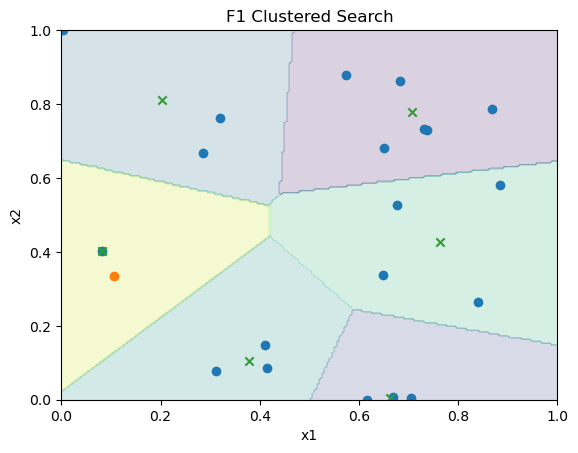

In [24]:
X = np.load("f1initial_inputs.npy")

x_next = np.load("f1_next_bbo11_2.npy")

plot_with_clusters(X, x_next, title="F1 Clustered Search")

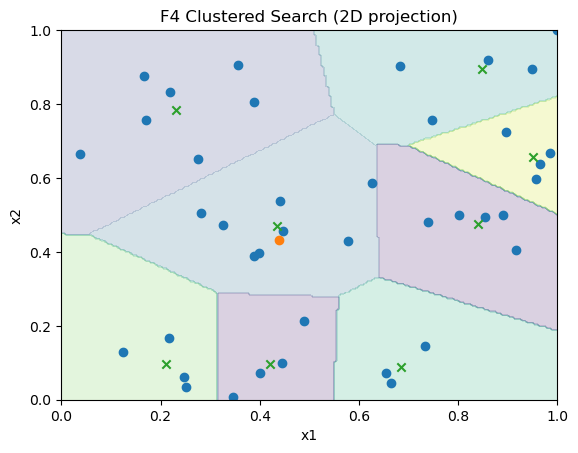

In [27]:
X = np.load("f4initial_inputs.npy")

x_next = np.load("f4_next_bbo11_2.npy")

plot_with_clusters(X, x_next, title="F4 Clustered Search")

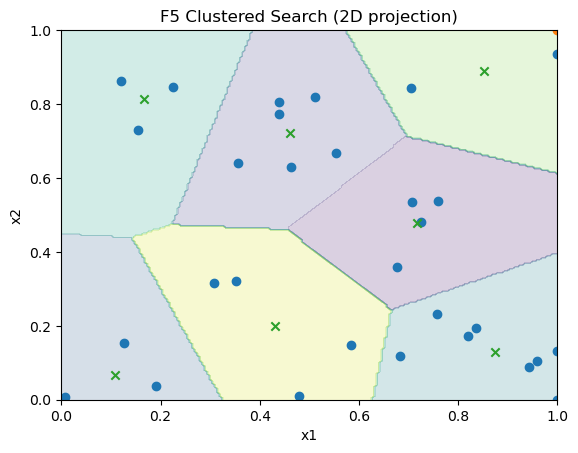

In [28]:
X = np.load("f5initial_inputs.npy")

x_next = np.load("f5_next_bbo11_2.npy")

plot_with_clusters(X, x_next, title="F5 Clustered Search")

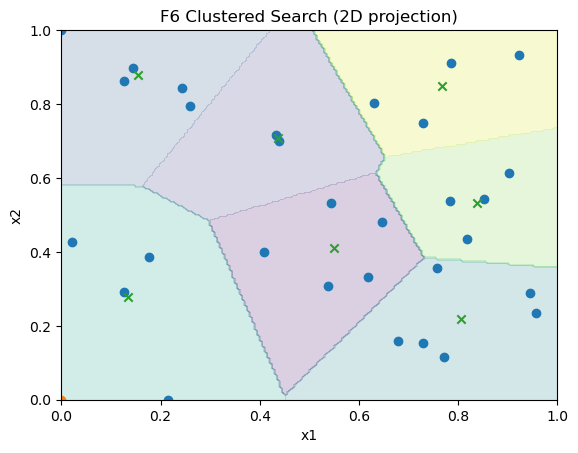

In [29]:
X = np.load("f6initial_inputs.npy")

x_next = np.load("f6_next_bbo11_2.npy")

plot_with_clusters(X, x_next, title="F6 Clustered Search")

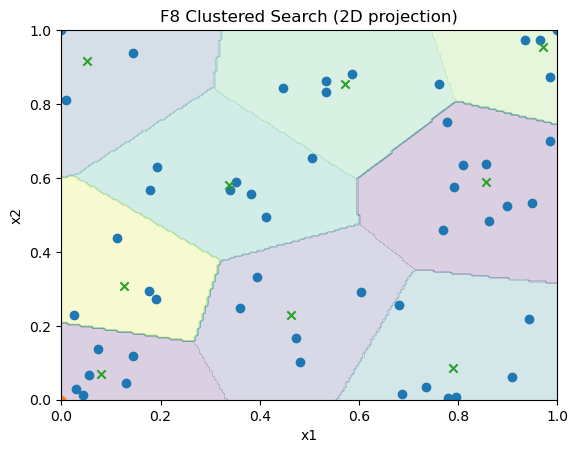

In [30]:
X = np.load("f8initial_inputs.npy")

x_next = np.load("f8_next_bbo11_2.npy")

plot_with_clusters(X, x_next, title="F8 Clustered Search")